## Packages and env setup

In [1]:
# pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

In [2]:
# pip install transformers

In [3]:
# pip install datasets

In [4]:
# ps aux | grep python

In [5]:
# ps aux | grep python

In [6]:
# nvidia-smi

In [7]:
# pip install peft

In [8]:
# pip install --upgrade tran\sformers peft accelerate

In [59]:
# pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 103.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 78.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 113.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


## Constants

In [9]:
model_name = 'gpt2'
dataset_name = 'tatsu-lab/alpaca'

In [10]:
from transformers import AutoModelForCausalLM, AutoTokenizer

In [11]:
from peft import LoraConfig, get_peft_model, TaskType

## Tokenizer and Model

In [12]:
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(model_name)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [13]:
lora_config = LoraConfig(
    r=16,                      # rank
    lora_alpha=32,
    target_modules=["c_attn"],  # GPT-2 attention layer
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

In [14]:
model = get_peft_model(model, lora_config)

/venv/main/lib/python3.12/site-packages/peft/tuners/lora/layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


## Workaround with Tokens

In [15]:
text = 'hello, i\'m wimukthi'
tokens = tokenizer(text)
print(tokens)

{'input_ids': [31373, 11, 1312, 1101, 266, 320, 2724, 400, 72], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [16]:
# print(tokenizer.decode(tokens))

In [17]:
texts = ['hello, i\'m wimukthi', 'i love coding', 'living in Australia']
tokens_obj = tokenizer(texts)
print(tokens_obj)

{'input_ids': [[31373, 11, 1312, 1101, 266, 320, 2724, 400, 72], [72, 1842, 19617], [19950, 287, 4505]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1], [1, 1, 1]]}


In [18]:
for t in tokens_obj['input_ids']:
  print(tokenizer.decode(t))

hello, i'm wimukthi
i love coding
living in Australia


## LoRA

## Load Dataset

In [19]:
from datasets import load_dataset

In [20]:
dataset = load_dataset(dataset_name)
split = dataset["train"].shuffle(seed=42).select(range(10000)).train_test_split(test_size=0.2)

train_dataset = split["train"]
val_dataset = split["test"]

In [21]:
split

DatasetDict({
    train: Dataset({
        features: ['instruction', 'input', 'output', 'text'],
        num_rows: 8000
    })
    test: Dataset({
        features: ['instruction', 'input', 'output', 'text'],
        num_rows: 2000
    })
})

In [22]:
train_dataset

Dataset({
    features: ['instruction', 'input', 'output', 'text'],
    num_rows: 8000
})

In [23]:
val_dataset

Dataset({
    features: ['instruction', 'input', 'output', 'text'],
    num_rows: 2000
})

## Preprocess

In [24]:
def preprocess(example):
    if example['input'].strip() != "":
        prompt = f"Instruction: {example['instruction']}\nInput: {example['input']}\nAnswer:"
    else:
        prompt = f"Instruction: {example['instruction']}\nAnswer:"
    labels = example['output']
    return {"prompt": prompt, "labels": labels}

In [25]:
# ds_train, ds_val = ds['train'], ds['validation']

In [26]:
ds_train = train_dataset.map(preprocess)
ds_val = val_dataset.map(preprocess)

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [27]:
ds_train[:10]

{'instruction': ['List at least 3 benefits of eating healthy.',
  'Describe the motion of a ball rolling off the edge of a table.',
  'Brainstorm three questions an interviewer could ask prior to a job interview.',
  'Classify the movie genres from the given context.',
  'Translate the following sentence into Spanish: "May I have a cup of coffee?".',
  'Create a poem that uses vivid imagery.',
  'Create a graphic representation of the given data.',
  'Explain the process of cellular respiration in plants.',
  'Describe what historical research requires.',
  'Generate a list of 10 adjectives to describe a castle.'],
 'input': ['',
  '',
  '',
  'This movie tells the story of two brothers who were both born with magical powers.',
  '',
  '',
  'Data: Average Daily Temperature in January for 5 Different Cities.\nNew York: 12°C, Boston: 11°C, London: 3°C, Paris: 4°C, Tokyo: 6°C',
  '',
  '',
  ''],
 'output': ['Three benefits of eating healthy are improved physical health, improved mental 

## Tokenization

In [28]:
def tokenize(batch):
    # Ensure inputs are lists of strings
    prompts = batch["prompt"]
    labels = batch["labels"]

    encodings = tokenizer(
        prompts,
        truncation=True,
        padding="max_length",
        max_length=512
    )

    label_encodings = tokenizer(
        labels,
        truncation=True,
        padding="max_length",
        max_length=128
    )

    # Assign label input_ids
    encodings["labels"] = label_encodings["input_ids"]

    return encodings

In [29]:
ds_train.column_names

['instruction', 'input', 'output', 'text', 'prompt', 'labels']

In [30]:
# tokenized_ds = ds_train.map(tokenize, batched=True, batch_size=512, remove_columns=['instruction', 'input', 'output', 'text', 'prompt', 'labels'])


train_dataset_tokenized = ds_train.map(
    tokenize,
    batched=True,
    batch_size=64,  # smaller batch size for map to avoid memory issues
    remove_columns=ds_train.column_names
)

val_dataset_tokenized = ds_val.map(
    tokenize,
    batched=True,
    batch_size=64,
    remove_columns=ds_val.column_names
)

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [31]:
# tokenized_ds

In [32]:
train_dataset_tokenized.set_format(type='torch')
val_dataset_tokenized.set_format(type='torch')

In [33]:
# map_kwargs = {
#     'batched': True,
#     'batch_size': 512,
#     'remove_columns': ['idx', 'sentence', 'label']
# }
# tokenized_dataset_train = ds_train.map(tokenize, **map_kwargs)
# tokenized_dataset_val = ds_val.map(tokenize, **map_kwargs)

In [34]:
# tokenized_dataset_train[:4]

In [35]:
# for i, j in enumerate(tokenized_dataset_train[:4]['input_ids']):
#   print(f'{i+1}: {tokenizer.decode(j)}')

In [36]:
# print(len(tokenized_dataset_train), len(tokenized_dataset_val))

In [37]:
# tokenized_dataset_train = tokenized_dataset_train.filter(lambda x: len(x['input_ids']) > 5)
# tokenized_dataset_val = tokenized_dataset_val.filter(lambda x: len(x['input_ids']) > 5)

In [38]:
# print(len(tokenized_dataset_train), len(tokenized_dataset_val))

In [39]:
# tokenized_dataset_train.set_format(type='torch')
# tokenized_dataset_val.set_format(type='torch')

In [40]:
# tokenized_dataset_train[:5]

In [41]:
# print(tokenizer.pad_token)

In [42]:
print(train_dataset_tokenized[0])

{'labels': tensor([12510,  4034,   286,  6600,  5448,   389,  6596,  3518,  1535,    11,
         6596,  5110,  1535,    11,   290,   257, 11832,  2526,   286, 10726,
        10040,    13, 37537,  5448,   460,  1037,  5529,   257,  5448,  3463,
          290,  4646,   262,  2526,   286,  2612,  4369,    11, 12593,    11,
          290,  1728,  3858,   286,  4890,    13, 12032,    11,  6600,  5448,
          460,  4646,  5503,    11,  5750,  2568,  2974,    11,   290,  2620,
         4088,   290, 10368,    13, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 502

## Collator

In [43]:
from transformers import DataCollatorForLanguageModeling
from torch.utils.data import DataLoader

In [44]:
tokenizer.pad_token = tokenizer.eos_token

In [45]:
data_collator = DataCollatorForLanguageModeling(tokenizer, mlm=False)

dataloader_param = {
    'batch_size': 8,
    'collate_fn': data_collator,
    'shuffle': True
}
train_dataloader = DataLoader(train_dataset_tokenized, **dataloader_param)
val_dataloader = DataLoader(val_dataset_tokenized, **dataloader_param)

In [46]:
len(train_dataloader)

1000

In [47]:
# batch = next(iter(train_dataloader))
# print(batch.keys())

In [48]:
# batch['input_ids'].shape

In [49]:
# batch['input_ids'][0]

In [50]:
# batch['labels'][0]

In [51]:
# batch['attention_mask'][0]

## Optimizer

In [52]:
import torch

In [77]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [78]:
# def validate(epoch):
#   model.eval()
#   total_loss = 0.0
#   for i, batch in enumerate(val_dataloader):
#     batch = {k: v.to(device) for k, v in batch.items()}
#     optimizer.zero_grad()
#     with torch.cuda.amp.autocast():
#       outputs = model(**batch)
#       loss = outputs.loss
#       total_loss += loss.item()
#   print(f'validation loss at epoch {epoch}: {total_loss/len(val_dataloader)}')

In [79]:
len(train_dataloader)

1000

## Training

In [80]:
num_epochs = 3
train_losses = []
val_losses = []


model.to(device)

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0.0
    for i, batch in enumerate(train_dataloader):
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        print("loss:", loss.item())
        if i % 100 == 0:
            print(f"Epoch {epoch+1}, Step {i}, Train Loss: {loss.item():.4f}")

    avg_train_loss = total_train_loss / len(train_dataloader)
    train_losses.append(avg_train_loss)
    print(f"Epoch {epoch+1} completed. Avg Train Loss: {avg_train_loss:.4f}")

    # --------------------------
    # Validation
    # --------------------------
    model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for batch in val_dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            val_loss = outputs.loss
            total_val_loss += val_loss.item()
    avg_val_loss = total_val_loss / len(val_dataloader)
    val_losses.append(avg_val_loss)
    print(f"Epoch {epoch+1} completed. Avg Validation Loss: {avg_val_loss:.4f}")

loss: 2.2235844135284424
Epoch 1, Step 0, Train Loss: 2.2236
loss: 2.219660997390747
loss: 2.0058345794677734
loss: 2.3235645294189453
loss: 2.6917765140533447
loss: 1.9561336040496826
loss: 2.151785135269165
loss: 2.1590209007263184
loss: 2.2490310668945312
loss: 2.425354242324829
loss: 1.8679052591323853
loss: 2.2155704498291016
loss: 2.1260178089141846
loss: 2.498629331588745
loss: 2.2778608798980713
loss: 2.1548640727996826
loss: 2.1962969303131104
loss: 1.975401759147644
loss: 2.450127601623535
loss: 2.1836018562316895
loss: 2.299722194671631
loss: 2.366651773452759
loss: 2.166806221008301
loss: 2.091360330581665
loss: 2.291327714920044
loss: 2.0950632095336914
loss: 2.1993625164031982
loss: 2.50732421875
loss: 2.4408328533172607
loss: 2.201542377471924
loss: 2.1087684631347656
loss: 1.971053123474121
loss: 2.1818809509277344
loss: 2.1366279125213623
loss: 2.090912103652954
loss: 1.9612818956375122
loss: 2.6221120357513428
loss: 1.9982047080993652
loss: 2.7744221687316895
loss: 2.

In [81]:
print(train_losses, val_losses)

[2.228861065030098, 2.174304403781891, 2.1394238585829735] [2.151888388633728, 2.139827848911285, 2.1383235273361207]


## Visualization

In [82]:
import matplotlib.pyplot as plt

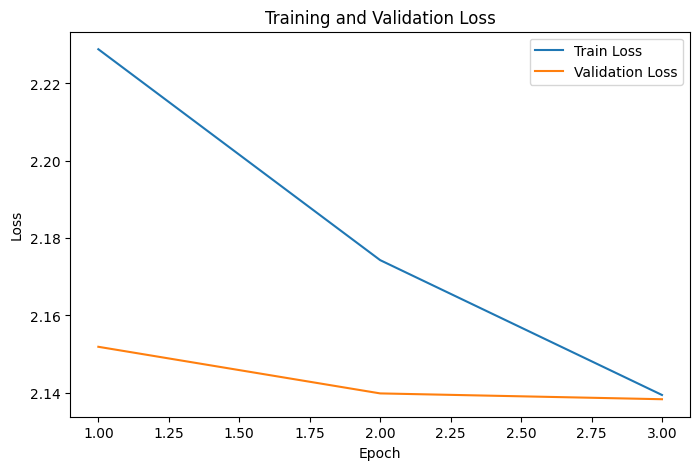

In [83]:
plt.figure(figsize=(8,5))
plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

## Save Model

In [85]:
saving_format = f'{model_name.split('/')[-1]}-{dataset_name.split('/')[-1]}'

In [86]:
model.save_pretrained(f'/sft_model-{saving_format}')

In [87]:
tokenizer.save_pretrained(f'/sft_model-{saving_format}')

('/sft_model-gpt2-alpaca/tokenizer_config.json',
 '/sft_model-gpt2-alpaca/tokenizer.json')

## Evaluate

In [88]:
model.eval()
prompt = 'Instruction: Summarizing the following text. \nInput: Machine learning models require a lot of data and resources to perform well.\nAnswer:'
input = tokenizer(prompt, return_tensors='pt').to(device)
output = model.generate(**input, max_new_tokens=50)
print(tokenizer.decode(output[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Instruction: Summarizing the following text. 
Input: Machine learning models require a lot of data and resources to perform well.
Answer: Machine learning models require a lot of data and resources to perform well.
Answer: Machine learning models require a lot of data and resources to perform well.
Answer: Machine learning models require a lot of data and resources to perform well.
Answer


In [89]:
model.eval()
prompt = 'Instruction: Explain. \nInput: What is machine learning.\nAnswer:'
input = tokenizer(prompt, return_tensors='pt').to(device)
output = model.generate(**input, max_new_tokens=50)
print(tokenizer.decode(output[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Instruction: Explain. 
Input: What is machine learning.
Answer: Machine learning is a new field of research that uses machine learning techniques to analyze data and analyze the data. Machine learning is a technique that allows a computer to learn a data set from a set of data points and then classify the data into a set of


In [91]:
base_model = AutoModelForCausalLM.from_pretrained("gpt2")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [92]:
model.from_pretrained(base_model, f'/sft_model-{saving_format}')

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): GPT2LMHeadModel(
      (transformer): GPT2Model(
        (wte): Embedding(50257, 768)
        (wpe): Embedding(1024, 768)
        (drop): Dropout(p=0.1, inplace=False)
        (h): ModuleList(
          (0-11): 12 x GPT2Block(
            (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (attn): GPT2Attention(
              (c_attn): lora.Linear(
                (base_layer): Conv1D(nf=2304, nx=768)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=768, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=2304, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
         